## Goal

Here, we finally try to create a credible interval (CI) for the compartment transitions, getting a confidence estimate on the exact position of the transitions. 

### Method: bootstrapping

We will use bootstrapping to resample the 'z' variable from the trace of a  model (across chains and draws), and calculate the mean each time. 


## Load a trace

In [1]:
import arviz as az

name = "T_N_HN_10"
trace = az.from_netcdf(f"../results/traces/{name}_z_trace.nc")

In [2]:
trace.posterior

<xarray.Dataset> Size: 491MB
Dimensions:      (chain: 7, draw: 1500, pos: 1460, mu_dim_0: 2, sigma_dim_0: 2)
Coordinates:
  * chain        (chain) int64 56B 0 1 2 3 4 5 6
  * draw         (draw) int64 12kB 0 1 2 3 4 5 ... 1494 1495 1496 1497 1498 1499
  * pos          (pos) int64 12kB 24 25 26 27 28 29 ... 1617 1618 1619 1620 1621
  * mu_dim_0     (mu_dim_0) int64 16B 0 1
  * sigma_dim_0  (sigma_dim_0) int64 16B 0 1
Data variables:
    eps          (chain, draw, pos) float64 123MB ...
    z            (chain, draw, pos) int64 123MB ...
    mu           (chain, draw, mu_dim_0) float64 168kB ...
    sigma        (chain, draw, sigma_dim_0) float64 168kB ...
    grw_sigma    (chain, draw) float64 84kB ...
    logit_w      (chain, draw, pos) float64 123MB ...
    w            (chain, draw, pos) float64 123MB ...
Attributes:
    created_at:                 2025-07-02T10:07:48.044236+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.22.0
    sampling_time:              1695.637930393219
    tuning_steps:               1500

First, we will stack the chains and draws per `pos`, so we have $7 * 1500$ samples per position.

In [3]:
stacked = trace.posterior.z.stack(
    sample=["chain", "draw"])
stacked

<xarray.DataArray 'z' (pos: 1460, sample: 10500)> Size: 123MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1460, 10500))
Coordinates:
  * pos      (pos) int64 12kB 24 25 26 27 28 29 ... 1617 1618 1619 1620 1621
  * sample   (sample) object 84kB MultiIndex
  * chain    (sample) int64 84kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 84kB 0 1 2 3 4 5 6 ... 1494 1495 1496 1497 1498 1499

Then, we define a wrapper function to bootstrap the mean for each position, then calculate the quantiles (CI) for the bootstrapped means.

In [4]:
from scipy.stats import bootstrap
import numpy as np

def bootstrap_mean(data, **kwargs):
    """Compute the confidence interval for the mean."""
    res = bootstrap(
        (data,),
        statistic = np.mean,
        vectorized = True,
        axis=1,
        method = "basic",
        **kwargs
    )

    return res


def compute_batch(arr, max_bytes=16 * 1024**3):
    """
    Compute max batch size so that each batch of resamples fits in max_bytes.
    """
    # Elements in a single resample
    n_elements = arr.shape[0] * arr.shape[1]
    # Bytes per element
    bytes_per_elem = np.dtype(arr.dtype).itemsize
    # Bytes per resample
    bytes_per_resample = n_elements * bytes_per_elem
    # Max batches
    batch = max(1, int(max_bytes // bytes_per_resample))
    return batch



In [5]:
compute_batch(stacked.values)

140

Then, try it out:

In [6]:
bootstrap_results = bootstrap_mean(
    stacked, **{
        "confidence_level": 0.99,
        "n_resamples": 10000,
        "batch": compute_batch(stacked.values)
        }
    )

bootstrap_results

BootstrapResult(confidence_interval=ConfidenceInterval(low=array([ 1.90476190e-04, -1.90476190e-04,  9.52380952e-05, ...,
        5.93328571e-02,  7.20947619e-02,  2.95238095e-03], shape=(1460,)), high=array([0.00180952, 0.00095238, 0.00180952, ..., 0.07152381, 0.086     ,
       0.00638095], shape=(1460,))), bootstrap_distribution=array([[0.00085714, 0.00057143, 0.00095238, ..., 0.00114286, 0.0007619 ,
        0.00133333],
       [0.00047619, 0.00085714, 0.00057143, ..., 0.00019048, 0.00057143,
        0.00038095],
       [0.00095238, 0.00133333, 0.00085714, ..., 0.00095238, 0.00180952,
        0.0007619 ],
       ...,
       [0.05990476, 0.06561905, 0.06771429, ..., 0.06619048, 0.06428571,
        0.06590476],
       [0.07561905, 0.0787619 , 0.08      , ..., 0.07761905, 0.07933333,
        0.08028571],
       [0.00552381, 0.00542857, 0.00466667, ..., 0.00342857, 0.004     ,
        0.00428571]], shape=(1460, 10000)), standard_error=array([0.00031469, 0.0002111 , 0.00031442, ..., 0.00

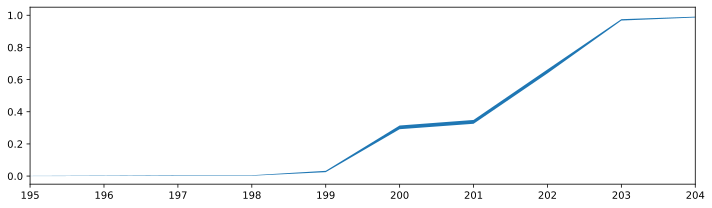

In [13]:
import matplotlib.pyplot as plt
import matplotlib_inline 

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

x = stacked.pos.values
lower = bootstrap_results.confidence_interval.low
upper = bootstrap_results.confidence_interval.high

fig, ax = plt.subplots(figsize=(10, 3))

ax.fill_between(
    x,
    lower,
    upper,
    label="95% CI",
    # ec = "black",
)
ax.set_xlim(195,204)
plt.tight_layout()

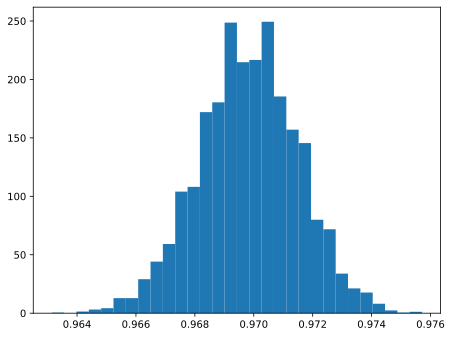

In [8]:
plt.hist(bootstrap_results.bootstrap_distribution[1000], density=True, bins=30)
plt.tight_layout()

In [24]:
bootstrap_99 = bootstrap_mean(
    stacked, **{
    "n_resamples": 0,
    #"batch": compute_batch(stacked.values),
    "confidence_level": 0.99,
    "bootstrap_result": bootstrap_results
    }
    )

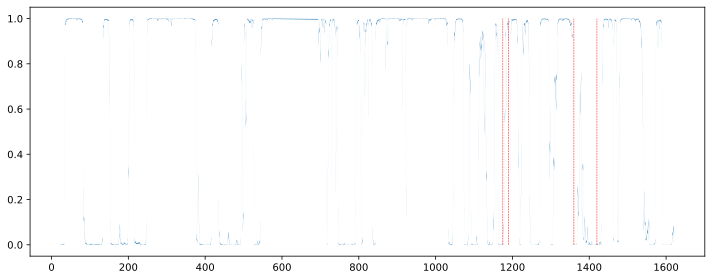

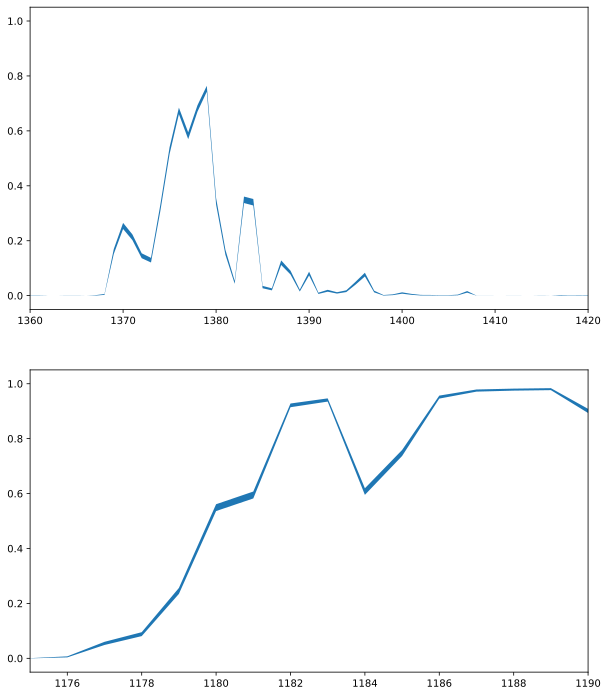

In [77]:
lower_99 = bootstrap_99.confidence_interval.low
upper_99 = bootstrap_99.confidence_interval.high

fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(
    x,
    lower_99,
    upper_99, 
)
zooms = [(1360,1420), (1175, 1190)]

ax.vlines(zooms, 0, 1, color="red", linestyle="--", linewidth=0.5)

f,axs = plt.subplots(len(zooms), figsize = (10, 6*len(zooms)))

for i,zoom in enumerate(zooms):
    zax = axs[i]
    zax.fill_between(
        x,
        lower_99,
        upper_99,
    )
    zax.set_xlim(zoom)



# ax[1].fill_between(
#     x,
#     lower_99,
#     upper_99, 
# )
# ax[1].set_xlim(zoom)

fig.tight_layout()
plt.show()